# F1 Exploratory Data Analysis
Goal: understand the data broadly first, then investigate what stands out.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('../data/processed/cleaned_dataset.csv')
print('Shape:', df.shape)
df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25716\3467997453.py:9: DtypeWarning: Columns (38,44,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/cleaned_dataset.csv')


Shape: (320274, 65)


,raceId,year,round,circuit_name,location,country,date,driverId,driverRef,code,constructor_name,lap,position,grid,milliseconds,cum_time_ms,gap_to_leader_ms,pit_stop_this_lap,cumulative_pit_stops,laps_since_last_pit,pit_duration_ms,statusId,points,positionOrder,won,total_laps,race_progress,position_vs_grid,position_change,rolling_lap_time_ms,pace_delta_to_fastest_ms,gap_to_leader_s,gap_per_lap_covered_s,tire_age_ratio,gap_to_ahead_ms,drs_zone_proxy,pit_window_proxy,driver_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed,pit_stop_duration_s,compound,stint_number,tyre_age_at_stint_start,date_openf1,pressure,track_temperature,rainfall,wind_speed,wind_direction,humidity,air_temperature,meeting_key,session_key,anomalous_lap_time
0,841,2011,1,Albert Park Grand Prix Circuit,Melbourne,Australia,2011-03-27,20,vettel,VET,Red Bull,1,1,1,98109,98109,0,0,0,1,0.0,1,25.0,1,1,58,0.017241,0,0.0,98109.0,0,0.000,0.000,0.017241,0.0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,841,2011,1,Albert Park Grand Prix Circuit,Melbourne,Australia,2011-03-27,1,hamilton,HAM,McLaren,1,2,2,100573,100573,2464,0,0,1,0.0,1,18.0,2,0,58,0.017241,0,0.0,100573.0,2464,2.464,2.464,0.017241,2464.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,841,2011,1,Albert Park Grand Prix Circuit,Melbourne,Australia,2011-03-27,17,webber,WEB,Red Bull,1,3,3,101467,101467,3358,0,0,1,0.0,1,10.0,5,0,58,0.017241,0,0.0,101467.0,3358,3.358,3.358,0.017241,894.0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,841,2011,1,Albert Park Grand Prix Circuit,Melbourne,Australia,2011-03-27,808,petrov,PET,Renault,1,4,6,102835,102835,4726,0,0,1,0.0,1,15.0,3,0,58,0.017241,2,0.0,102835.0,4726,4.726,4.726,0.017241,1368.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,841,2011,1,Albert Park Grand Prix Circuit,Melbourne,Australia,2011-03-27,13,massa,MAS,Ferrari,1,5,8,104196,104196,6087,0,0,1,0.0,1,6.0,7,0,58,0.017241,3,0.0,104196.0,6087,6.087,6.087,0.017241,1361.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


won
0    303146
1     17128
Name: count, dtype: int64

won
0    94.65
1     5.35
Name: proportion, dtype: float64


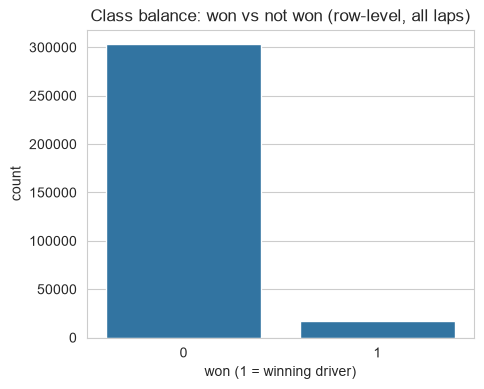

In [6]:
win_counts = df['won'].value_counts()
win_pct = df['won'].value_counts(normalize=True) * 100
print(win_counts)
print()
print(win_pct.round(2))

plt.figure(figsize=(5,4))
sns.countplot(x='won', data=df)
plt.title('Class balance: won vs not won (row-level, all laps)')
plt.xlabel('won (1 = winning driver)')
plt.show()

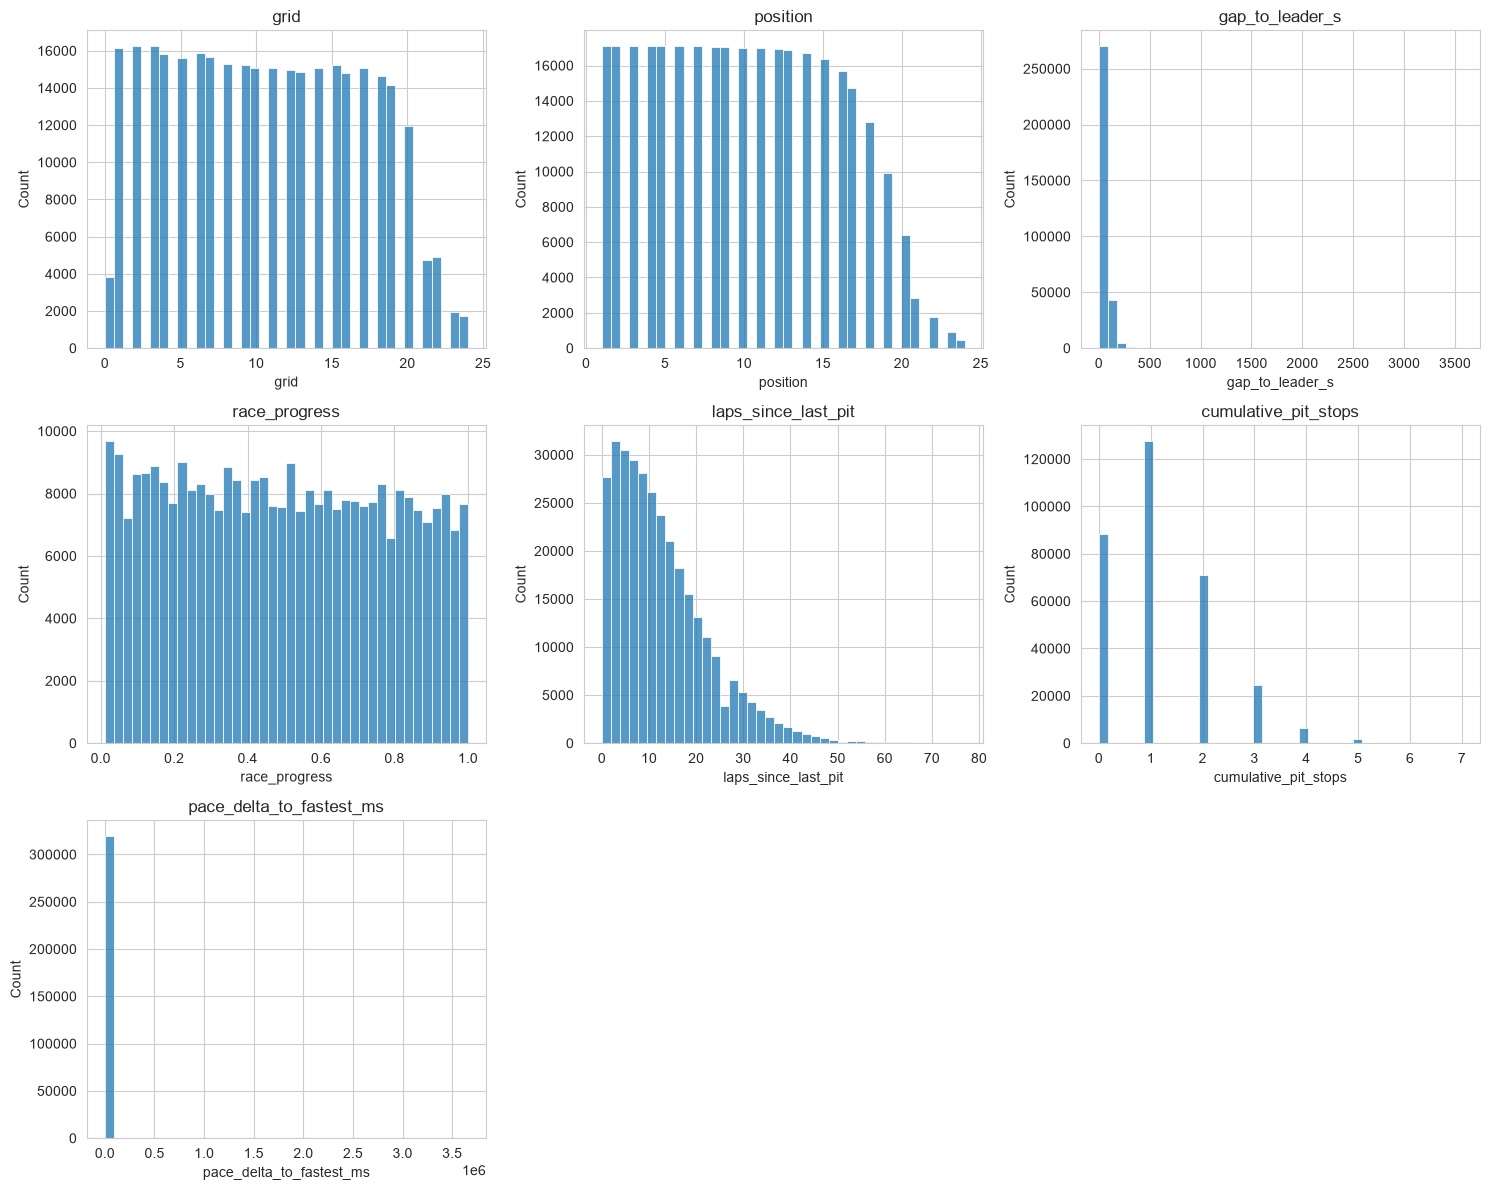

In [7]:
key_features = ['grid', 'position', 'gap_to_leader_s', 'race_progress',
                 'laps_since_last_pit', 'cumulative_pit_stops', 'pace_delta_to_fastest_ms']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(key_features):
    if col in df.columns:
        sns.histplot(df[col].dropna(), bins=40, ax=axes[i])
        axes[i].set_title(col)
for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [8]:
extreme_gap = df[df['gap_to_leader_s'] > 500]
print("Rows with gap_to_leader_s > 500s:", len(extreme_gap))
print("Of those, how many are flagged as anomalous_lap_time:", extreme_gap['anomalous_lap_time'].sum())

Rows with gap_to_leader_s > 500s: 271
Of those, how many are flagged as anomalous_lap_time: 128


In [15]:
df = pd.read_csv('../data/processed/cleaned_dataset.csv')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['raceId', 'driverId', 'driver_number', 'session_key', 'meeting_key', 'round', 'year']
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr_with_won = df[numeric_cols].corr()['won'].sort_values(ascending=False)
print(corr_with_won)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25716\3695935182.py:1: DtypeWarning: Columns (38,44,46,47,48,51,54) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/cleaned_dataset.csv')


won                         1.000000
points                      0.638177
drs_zone_proxy              0.303568
race_progress               0.013725
lap                         0.013210
laps_since_last_pit         0.008933
tire_age_ratio              0.008368
pit_window_proxy            0.007832
cum_time_ms                 0.007456
track_temperature           0.005748
position_vs_grid            0.004947
has_openf1_telemetry        0.001115
wind_direction              0.000971
anomalous_lap_time          0.000645
pit_duration_ms             0.000373
pit_stop_duration_s         0.000133
i1_speed                   -0.000078
total_laps                 -0.000375
air_temperature            -0.000398
lap_duration               -0.000583
position_change            -0.000652
humidity                   -0.000710
i2_speed                   -0.001215
rainfall                   -0.001515
wind_speed                 -0.003182
pressure                   -0.003477
milliseconds               -0.003485
p